# TAPAS privacy analysis

Single entry point for the privacy half of the `benchmark_tapas` benchmark. Replaces the
separate `aggregate.py` / `tradeoff.py` / `attack_heatmap.py` / `plot_scores.py` scripts,
which now sit in `preseed_LEGACY/analysis/`.

**Provenance.** Every input below comes from the 2026-08-23 re-run, the first audit with a
correct per-fit generator seed. Results produced before that are invalid and live in
`preseed_LEGACY/`: `SynthcityGenerator` passed no `random_state`, so synthcity's default of 0
made every one of the 150 simulations byte-identical, giving an effective sample size of 2 and
forcing TP=1 / FP=0 for every generator. See the `seeds.py` and `common.py` docstrings.

**Inputs**

| path | written by |
|---|---|
| `results/scores/raw_scores_{method}.csv` | `common.run_method` (7 cols, pre-threshold scores) |
| `results/tables/benchmark_privacy_per_attack.csv` | `common.run_method` |
| `../results/utility_summary.csv`, `../results/fidelity_summary.csv` | `evaluation/eval_{utility,fidelity}.py` |

**Outputs** — figures render inline and are also written to `results/figures/`; tables to `results/tables/`.

Run top to bottom. Needs pandas, numpy, matplotlib, scipy. No sklearn, no tapas, no torch.

In [1]:
from pathlib import Path
import sys, glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde, mannwhitneyu

# Locate benchmark_tapas/ whether the notebook is run from there or from the repo root.
_cwd = Path.cwd()
BENCH = next(c for c in (_cwd, _cwd / "benchmark_tapas", _cwd.parent)
             if (c / "config.py").exists())
sys.path.insert(0, str(BENCH))
from config import (METHODS, METHOD_CONFIG, TABLES_DIR, FIGURES_DIR,
                    SCORES_DIR, UTILITY_RESULTS, FIDELITY_RESULTS)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Repo palette, inlined per convention (no shared palette module).
# Orange/charcoal only for 2-way splits: validated as a categorical pair
# (CVD dE 17.8 protan, normal-vision dE 29.5, contrast >= 3:1 on white).
# Sage/rose are NOT used to separate the four generators -- they fail CVD
# separation against each other (dE 5.9 protan, 10.8 normal). Generators are
# separated by position or marker instead.
ORANGE, CHARCOAL, SAGE, ROSE = "#CE4E36", "#3A3A3A", "#8CA9A0", "#D2B4B1"
INK, MUTED, GRID = "#3A3A3A", "#6B6B6B", "#DDDDDD"

LABELS = {"bayesian_network": "BN (no-DP)", "privbayes": "PrivBayes (DP)",
          "ctgan": "CTGAN (no-DP)", "dpgan": "DPGAN (DP)"}
SHORT  = {"bayesian_network": "BayesNet", "privbayes": "PrivBayes",
          "ctgan": "CTGAN", "dpgan": "DPGAN"}
ATTACK_ORDER = ["Groundhog", "ShadowModelling", "LocalNeighbourhood",
                "ProbabilityEstimation", "ClosestDistance"]
# What attack.attack_score actually returns, per family -- these are NOT commensurable,
# which is why each column carries its own scale.
SCORE_LABEL = {
    "Groundhog":             "RF P(member)",
    "ShadowModelling":       "RF P(member)",
    "LocalNeighbourhood":    "fraction of records in radius",
    "ProbabilityEstimation": "KDE log-density at target",
    "ClosestDistance":       "negative min L2 distance",
}
# A meaningful value on each attack's scale. NOT a "correct answer" -- correctness needs
# the label. These mark where the score means something interpretable on its own.
# ProbabilityEstimation has none: a KDE log-density has no natural reference point.
LANDMARK = {
    "Groundhog":          (0.5, "RF undecided"),
    "ShadowModelling":    (0.5, "RF undecided"),
    "LocalNeighbourhood": (0.0, "no record in radius"),
    "ClosestDistance":    (0.0, "record identical to target"),
}

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.facecolor": "white", "font.size": 10})


def auc(labels, scores):
    """Rank-based ROC AUC (Mann-Whitney U), ties averaged so an all-identical
    score column returns exactly 0.5 rather than an arbitrary value."""
    labels, scores = np.asarray(labels), np.asarray(scores)
    pos, neg = int((labels == 1).sum()), int((labels == 0).sum())
    if pos == 0 or neg == 0:
        return float("nan")
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty(len(scores), dtype=float)
    ranks[order] = np.arange(1, len(scores) + 1)
    s = scores[order]
    i = 0
    while i < len(s):
        j = i
        while j + 1 < len(s) and s[j + 1] == s[i]:
            j += 1
        if j > i:
            ranks[order[i:j + 1]] = (i + j + 2) / 2
        i = j + 1
    return float((ranks[labels == 1].sum() - pos * (pos + 1) / 2) / (pos * neg))


def null_halfwidth(n1, n2):
    """Half-width of the 95% band around AUC=0.5 for an attack with no signal.
    An AUC inside 0.5 +- this is indistinguishable from guessing."""
    return 1.96 * np.sqrt((n1 + n2 + 1) / (12 * n1 * n2))


def density(values, grid):
    """KDE, or None when the sample has no spread for a KDE to be defined."""
    values = np.asarray(values)
    if len(np.unique(values)) < 3 or np.std(values) == 0:
        return None
    try:
        return gaussian_kde(values)(grid)
    except np.linalg.LinAlgError:
        return None


def tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    ax.grid(axis="x", color=GRID, lw=0.6, alpha=0.5)
    ax.set_axisbelow(True)

print("benchmark_tapas:", BENCH)

benchmark_tapas: /Users/PengOlivia/Desktop/Uni/USYD VRI/priv-sdg/benchmark_tapas


## 1. Load and validate

Fails loudly rather than degrading to empty output. The previous `aggregate.py` silently wrote a
label-only `summary_utility.csv` because its inputs did not exist yet, and that empty table sat
in the repo unnoticed for a week -- hence the assertions here.

In [2]:
score_files = sorted(glob.glob(str(SCORES_DIR / "raw_scores_*.csv")))
assert score_files, f"no raw_scores_*.csv in {SCORES_DIR} -- run benchmark_tapas/scripts/run_*.py"

scores = pd.concat([pd.read_csv(f) for f in score_files], ignore_index=True)
scores["attack_short"] = scores["attack"].str.split("(").str[0]

per_attack_path = TABLES_DIR / "benchmark_privacy_per_attack.csv"
assert per_attack_path.exists(), f"missing {per_attack_path}"
per_attack = pd.read_csv(per_attack_path)
per_attack["attack_short"] = per_attack["attack"].str.split("(").str[0]

# Every generator must have been audited against the same target and the same
# background, or the four score distributions are not comparable.
assert scores["target_id"].nunique() == 1, \
    f"generators audited against different targets: {scores['target_id'].unique()}"

sizes = scores.groupby(["generator", "attack_short"]).size()
assert sizes.nunique() == 1, f"uneven test-set sizes across cells:\n{sizes[sizes != sizes.mode()[0]]}"
N_TEST = int(sizes.iloc[0])

balance = scores.groupby(["generator", "attack_short"])["ground_truth"].mean()
assert np.allclose(balance, 0.5), f"member/non-member imbalance:\n{balance[balance != 0.5]}"

N_POS = N_NEG = N_TEST // 2
HW = null_halfwidth(N_POS, N_NEG)

missing = set(METHODS) - set(scores["generator"])
if missing:
    print(f"WARNING: no scores for {sorted(missing)}")

print(f"{len(scores)} rows | {scores.generator.nunique()} generators "
      f"x {scores.attack_short.nunique()} attacks x {N_TEST} test datasets")
print(f"target_id {scores.target_id.iloc[0]}, balanced {N_POS}/{N_NEG}")
print(f"95% null band for AUC: [{0.5 - HW:.3f}, {0.5 + HW:.3f}]")

2000 rows | 4 generators x 5 attacks x 100 test datasets
target_id 12435, balanced 50/50
95% null band for AUC: [0.386, 0.614]


## 2. Mann-Whitney U test per generator x attack

The score distributions are not normal -- ClosestDistance is bimodal and LocalNeighbourhood piles
onto a handful of values -- so a rank-based test rather than a t-test.

**H0:** member and non-member raw scores come from the same distribution.
**H1:** they differ.

Two-sided, tie-corrected, one test per generator x attack, so 20 tests. Tie correction matters:
where scores pile onto two or three values it shrinks sigma by up to 50%, and the uncorrected
formula would be badly wrong for the LocalNeighbourhood column.

**Independence holds**, which is worth stating because the D+/D- datasets are emitted in pairs
and that looks like matching. It is not. `ExactDataKnowledge.generate_datasets` returns
`[self.training_dataset] * num_samples` -- the same background object every time -- so every D+
is built from the identical 499 records and so is every D-. D+_i and D-_i therefore share nothing
that D+_i and D-_j do not also share; the pairing is bookkeeping, not common randomness. The only
thing that varies across all 150 datasets is the per-fit generator seed. An unpaired test is
correct here, and a paired one would buy nothing.

(Under a weaker attacker model this would change. `AuxiliaryDataKnowledge` draws a fresh
background per simulation, which would make D+_i and D-_i genuinely coupled and require a paired
test.)

Two caveats do belong with any conclusion drawn here:

- **Low power.** At 50 per group only fairly large effects are detectable. "No difference found"
  is not "no difference exists".
- **One target.** Everything rests on a single target record drawn at seeds.TAPAS_TARGET_SEED.

In [3]:
ALPHA = 0.05

rows = []
for gen in [m for m in METHODS if m in set(scores.generator)]:
    for atk in [a for a in ATTACK_ORDER if a in set(scores.attack_short)]:
        cell = scores[(scores.generator == gen) & (scores.attack_short == atk)]
        mem = cell[cell.ground_truth == 1].raw_score.values
        non = cell[cell.ground_truth == 0].raw_score.values
        # scipy applies the tie correction and a continuity correction; matches R's
        # wilcox.test(exact=FALSE, correct=TRUE) to four decimals.
        U, pval = mannwhitneyu(mem, non, alternative="two-sided")
        rows.append({"generator": SHORT[gen], "attack": atk, "p": pval,
                     "U": U, "method": gen})
mw = pd.DataFrame(rows)

pvals = mw.pivot(index="generator", columns="attack", values="p")
pvals = pvals.reindex(index=[SHORT[m] for m in METHODS if m in set(scores.generator)],
                      columns=[a for a in ATTACK_ORDER if a in pvals.columns])

print("Mann-Whitney U / Wilcoxon rank-sum, two-sided, tie-corrected")
print("H0: member and non-member raw scores have the same distribution\n")
print(pvals.round(3).to_string())

n_sig = int((mw.p < ALPHA).sum())
print(f"\nsignificant at p < {ALPHA}: {n_sig} of {len(mw)}")
if n_sig:
    for _, r in mw[mw.p < ALPHA].sort_values("p").iterrows():
        print(f"  {r.generator} x {r.attack}: p = {r.p:.4f}")
else:
    closest = mw.nsmallest(2, "p")
    print("  closest: " + ", ".join(f"{r.generator} x {r.attack} (p = {r.p:.3f})"
                                    for _, r in closest.iterrows()))
    print(f"  with {len(mw)} tests you would expect about {len(mw) * ALPHA:.0f} "
          f"p < {ALPHA} by chance alone.")

# AUC is still computed -- the heatmap in section 5 uses it as a visual summary -- but the
# hypothesis test above, not the AUC, is what the conclusion rests on.
auc_tbl = (scores.groupby(["generator", "attack_short"])
                 .apply(lambda g: auc(g.ground_truth, g.raw_score), include_groups=False)
                 .unstack())
auc_tbl = auc_tbl.reindex(index=[m for m in METHODS if m in auc_tbl.index],
                          columns=[a for a in ATTACK_ORDER if a in auc_tbl.columns])
auc_tbl.index = [SHORT[m] for m in auc_tbl.index]
outside = (auc_tbl - 0.5).abs() > HW

cols = ["method", "attack", "auc", "tp", "fp", "mia_advantage", "eps_low_95"]
print("\nAs recorded by run_method (TP/FP at the trained threshold)")
print(per_attack[[c for c in cols if c in per_attack]]
      .sort_values(["method", "attack"]).round(3).to_string(index=False))

Mann-Whitney U / Wilcoxon rank-sum, two-sided, tie-corrected
H0: member and non-member raw scores have the same distribution

attack     Groundhog  ShadowModelling  LocalNeighbourhood  ProbabilityEstimation  ClosestDistance
generator                                                                                        
BayesNet       0.059            0.092               0.075                  0.551            0.173
PrivBayes      0.923            0.495               0.733                  0.687            0.501
CTGAN          0.112            0.555               0.526                  0.234            0.579
DPGAN          0.471            0.394               1.000                  0.612            0.051

significant at p < 0.05: 0 of 20
  closest: DPGAN x ClosestDistance (p = 0.051), BayesNet x Groundhog (p = 0.059)
  with 20 tests you would expect about 1 p < 0.05 by chance alone.

As recorded by run_method (TP/FP at the trained threshold)
          method                            

## 3. Separation

Does an attack tell member (D+) from non-member (D-) datasets? Member and non-member score
densities overlaid, one row per generator and one column per attack. If an attack worked, the
orange curve would sit to the right of the charcoal one.

The test result for every panel is in the table in section 2, deliberately not on the figure --
the curves show the shape of the evidence, the table quantifies it.

x is the raw score. It means something different in each column, so the scale is shared down a
column and never across -- drawn once on the bottom row, and labelled there with what the score
actually is. y is density, ticks hidden because only the shape and the overlap carry meaning.

Panels labelled "degenerate" have too few distinct values for a KDE. That is a finding about the
attack, not a plotting failure: LocalNeighbourhood scores the fraction of synthetic records
inside a radius, so when no record ever lands inside, every score is 0.0 and the attack is dead
rather than merely unlucky.

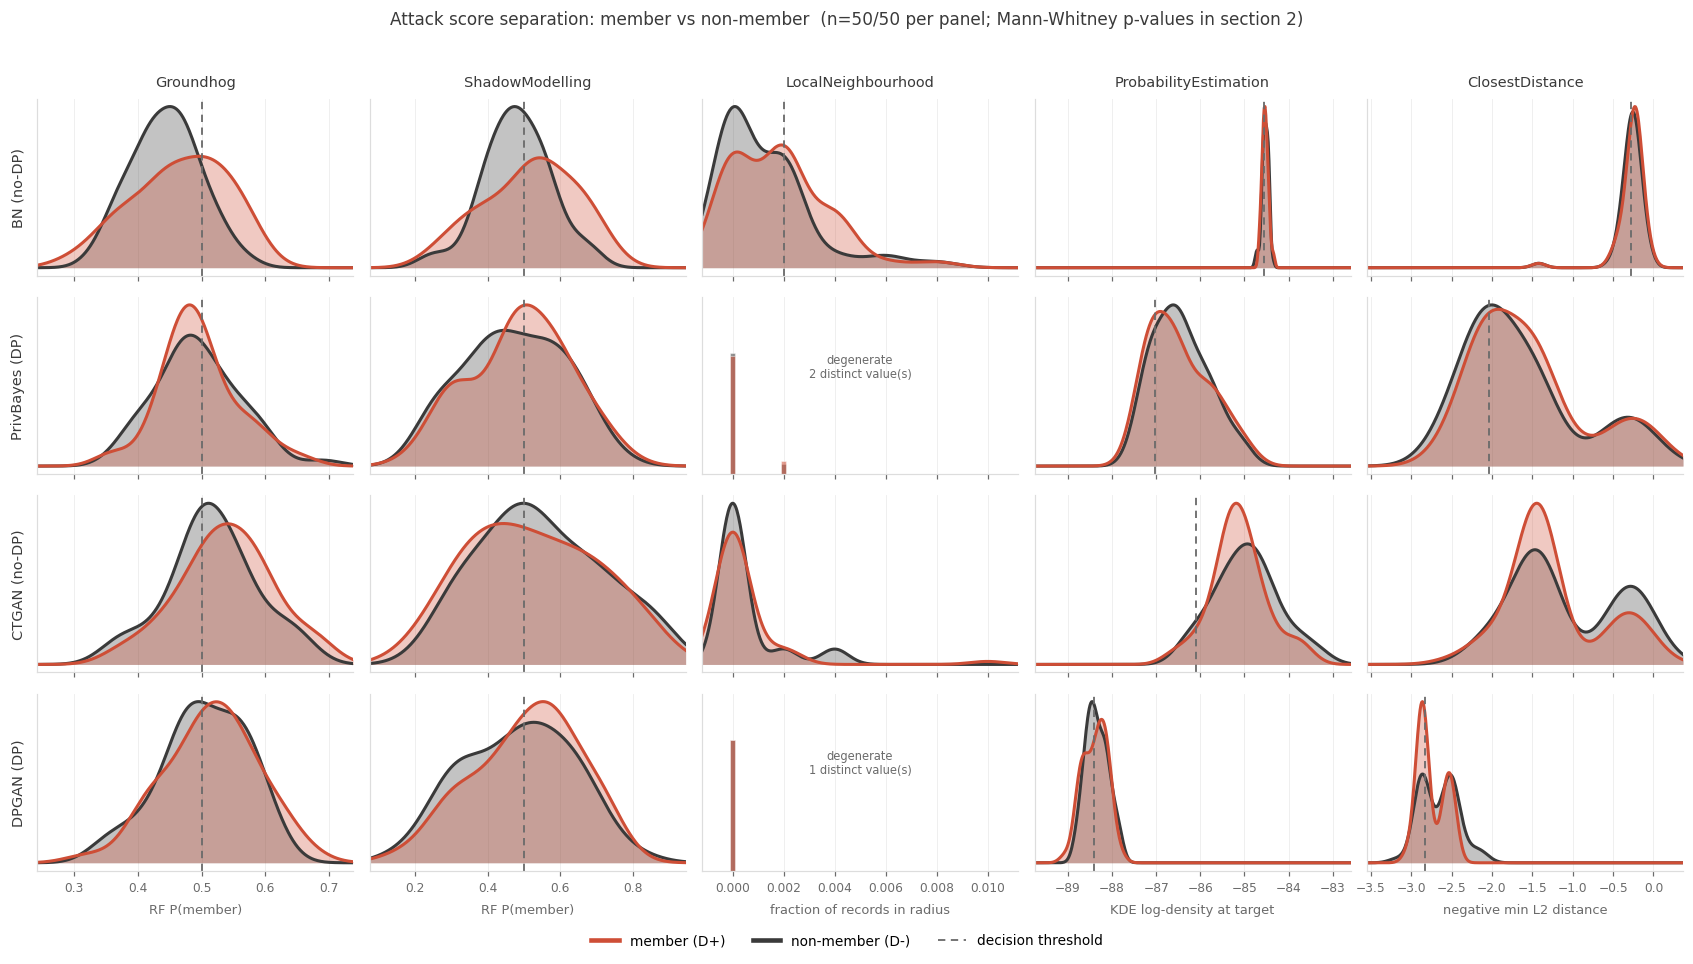

In [4]:
attacks = [a for a in ATTACK_ORDER if a in set(scores.attack_short)]
gens = [g for g in METHODS if g in set(scores.generator)]

# sharex="col": every column already has one scale, so draw it once on the bottom row
# instead of repeating four identical axes.
fig, axes = plt.subplots(len(gens), len(attacks), sharex="col",
                         figsize=(3.1 * len(attacks), 2.15 * len(gens)), squeeze=False)

for c, atk in enumerate(attacks):
    # NB: not named `col` -- the degenerate branch below rebinds that to a colour.
    sub = scores[scores.attack_short == atk]
    lo, hi = sub.raw_score.min(), sub.raw_score.max()
    pad = (hi - lo) * 0.12 if hi > lo else 0.5
    grid = np.linspace(lo - pad, hi + pad, 400)

    for r, gen in enumerate(gens):
        ax = axes[r][c]
        g = sub[sub.generator == gen]
        mem = g[g.ground_truth == 1].raw_score.values
        non = g[g.ground_truth == 0].raw_score.values

        dm, dn = density(mem, grid), density(non, grid)
        if dm is None or dn is None:
            w = (grid[-1] - grid[0]) / 60
            for vals, col in ((non, CHARCOAL), (mem, ORANGE)):
                u, cts = np.unique(vals, return_counts=True)
                ax.bar(u, cts / cts.sum(), width=w, color=col, alpha=0.55,
                       edgecolor="white", lw=0.5)
            ax.set_ylim(0, 1.35)
            ax.text(0.5, 0.55, f"degenerate\n{g.raw_score.nunique()} distinct value(s)",
                    transform=ax.transAxes, ha="center", fontsize=7.5, color=MUTED)
        else:
            ax.fill_between(grid, dn, color=CHARCOAL, alpha=0.30, lw=0)
            ax.fill_between(grid, dm, color=ORANGE, alpha=0.30, lw=0)
            ax.plot(grid, dn, color=CHARCOAL, lw=2)
            ax.plot(grid, dm, color=ORANGE, lw=2)

        thr = g.threshold.iloc[0]
        if np.isfinite(thr) and grid[0] <= thr <= grid[-1]:
            ax.axvline(thr, color=MUTED, ls=(0, (4, 3)), lw=1.2)

        ax.set_xlim(grid[0], grid[-1])
        ax.set_yticks([])
        tidy(ax)
        if r == 0:
            ax.set_title(atk, fontsize=9.5, color=INK, pad=8)
        if c == 0:
            ax.set_ylabel(LABELS[gen], fontsize=9.5, color=INK, labelpad=8)
        if r == len(gens) - 1:
            ax.set_xlabel(SCORE_LABEL.get(atk, "score"), fontsize=8.5, color=MUTED, labelpad=6)

fig.legend(handles=[Line2D([], [], color=ORANGE, lw=3, label="member (D+)"),
                    Line2D([], [], color=CHARCOAL, lw=3, label="non-member (D-)"),
                    Line2D([], [], color=MUTED, ls=(0, (4, 3)), lw=1.2, label="decision threshold")],
           loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.004))
fig.suptitle(f"Attack score separation: member vs non-member  "
             f"(n={N_POS}/{N_NEG} per panel; Mann-Whitney p-values in section 2)",
             fontsize=11, color=INK, y=1.0)
fig.tight_layout(rect=[0, 0.025, 1, 0.985])
fig.savefig(FIGURES_DIR / "score_separation.png", bbox_inches="tight")
plt.show()

## 4. Decisiveness

How confident is the attacker, ignoring whether it is right? Score spread per generator with the
ground-truth labels discarded. A tight pile means the attack cannot tell the datasets apart at
all; a wide spread means it is making strong calls, correct or not.

Generators are separated by vertical position rather than hue, because the palette's sage and
rose accents fail CVD separation against each other.

Two reference marks are drawn. The dashed grey line on each row is that generator's trained
decision threshold -- everything to its right was predicted "member", so a pile sitting entirely
on one side means the attack returned the same answer for all 100 datasets. The solid sage line
is a landmark interpretable on the attack's own scale: 0.5 where the random forest is undecided,
0 where no synthetic record falls inside the radius, 0 where a synthetic record sits exactly on
the target. Neither marks a "correct" score -- correctness depends on the label, which this plot
discards. ProbabilityEstimation has no landmark; a KDE log-density has no natural reference.

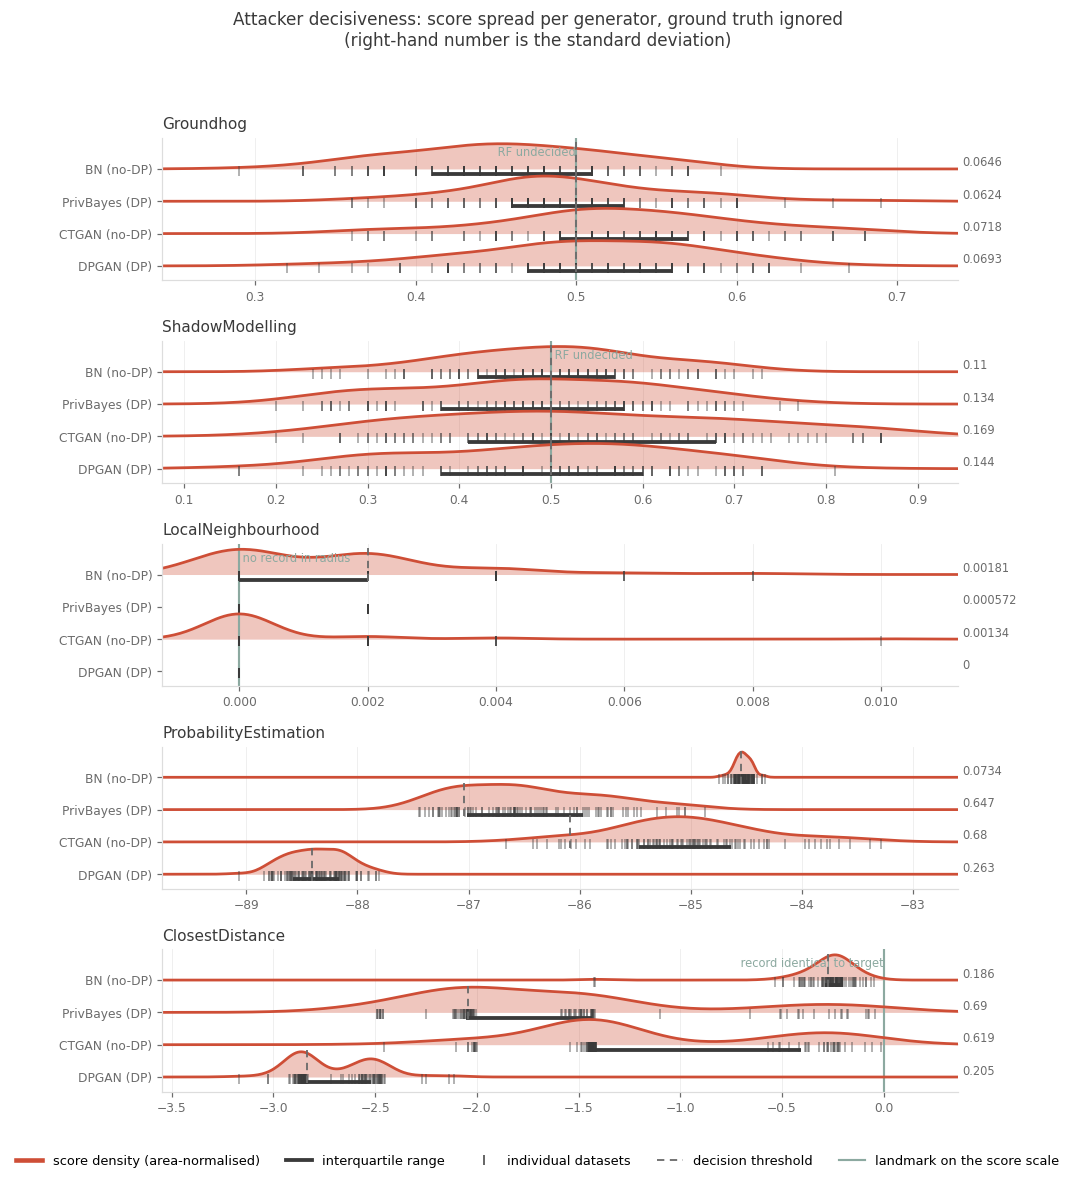

In [5]:
fig, axes = plt.subplots(len(attacks), 1, figsize=(9, 2.1 * len(attacks)), squeeze=False)

for r, atk in enumerate(attacks):
    ax = axes[r][0]
    row = scores[scores.attack_short == atk]
    lo, hi = row.raw_score.min(), row.raw_score.max()
    pad = (hi - lo) * 0.12 if hi > lo else 0.5
    grid = np.linspace(lo - pad, hi + pad, 400)

    for i, gen in enumerate(gens):
        vals = row[row.generator == gen].raw_score.values
        base = len(gens) - 1 - i
        dens = density(vals, grid)
        if dens is not None:
            dens = dens / dens.max() * 0.78
            ax.fill_between(grid, base, base + dens, color=ORANGE, alpha=0.32, lw=0)
            ax.plot(grid, base + dens, color=ORANGE, lw=1.8)
        ax.plot(vals, np.full_like(vals, base - 0.06), "|", color=CHARCOAL,
                ms=6, alpha=0.5, mew=1)
        ax.plot(np.percentile(vals, [25, 75]), [base - 0.16] * 2,
                color=CHARCOAL, lw=2.5, solid_capstyle="butt")
        ax.text(1.005, base + 0.18, f"{vals.std():.3g}", transform=ax.get_yaxis_transform(),
                fontsize=7.5, color=MUTED, va="center")
        # This generator's trained cutoff. Everything to its right was predicted "member";
        # a pile entirely on one side means the attack gave the same answer every time.
        thr = row[row.generator == gen].threshold.iloc[0]
        if np.isfinite(thr) and grid[0] <= thr <= grid[-1]:
            ax.plot([thr, thr], [base - 0.2, base + 0.85], color=MUTED,
                    ls=(0, (4, 3)), lw=1.2, zorder=4)

    # Landmark: a value interpretable on this attack's own scale (see LANDMARK).
    if atk in LANDMARK:
        lx, ltext = LANDMARK[atk]
        if grid[0] <= lx <= grid[-1]:
            ax.axvline(lx, color=SAGE, lw=1.4, zorder=1)
            ax.text(lx, len(gens) - 0.32, f" {ltext}", color=SAGE, fontsize=7.5,
                    va="top", ha="left" if lx < (grid[0] + grid[-1]) / 2 else "right")

    ax.set_xlim(grid[0], grid[-1])
    ax.set_yticks(range(len(gens)))
    ax.set_yticklabels([LABELS[g] for g in reversed(gens)], fontsize=9, color=INK)
    ax.set_ylim(-0.45, len(gens) - 0.05)
    ax.set_title(atk, fontsize=10, color=INK, loc="left", pad=6)
    tidy(ax)
    ax.grid(axis="y", visible=False)

fig.legend(handles=[Line2D([], [], color=ORANGE, lw=3, label="score density (area-normalised)"),
                    Line2D([], [], color=CHARCOAL, lw=2.5, label="interquartile range"),
                    Line2D([], [], color=CHARCOAL, marker="|", ls="none", label="individual datasets"),
                    Line2D([], [], color=MUTED, ls=(0, (4, 3)), lw=1.2, label="decision threshold"),
                    Line2D([], [], color=SAGE, lw=1.4, label="landmark on the score scale")],
           loc="lower center", ncol=5, frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, -0.012))
fig.suptitle("Attacker decisiveness: score spread per generator, ground truth ignored\n"
             "(right-hand number is the standard deviation)", fontsize=11, color=INK, y=1.0)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig(FIGURES_DIR / "score_decisiveness.png", bbox_inches="tight")
plt.show()

## 5. Attack heatmap

AUC by attack x generator. The colour scale spans exactly the 95% null band, so a cell only takes
on strong colour if it is statistically distinguishable from guessing -- saturation means
significance. Cells are hatched when they fall inside the band.

This replaces the old 0-1 scale, which was chosen when every cell was 0.0, 0.5 or 1.0.

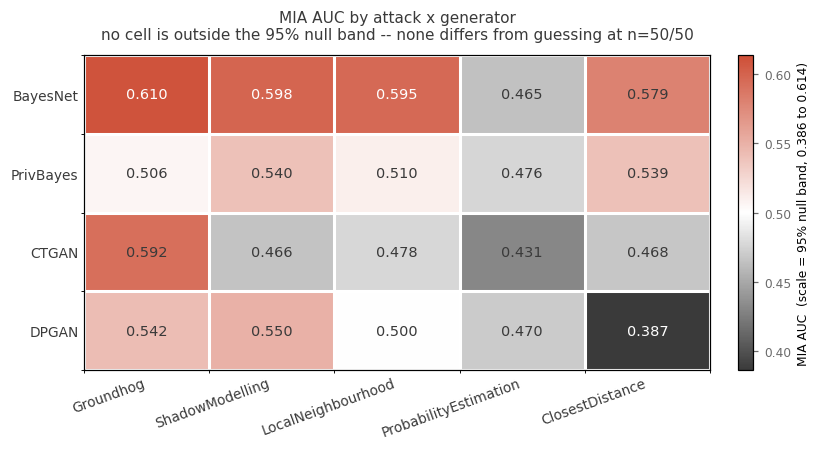

In [6]:
mat = auc_tbl.copy()
cmap = LinearSegmentedColormap.from_list("repo_div", [CHARCOAL, "#FFFFFF", ORANGE])

fig, ax = plt.subplots(figsize=(7.6, 4.2))
im = ax.imshow(mat.values, cmap=cmap, vmin=0.5 - HW, vmax=0.5 + HW, aspect="auto")

# Hatch only if it actually separates cells -- when nothing is significant,
# hatching all 20 is noise that obscures the numbers.
any_sig = bool(outside.values.any())
norm = plt.Normalize(0.5 - HW, 0.5 + HW)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if np.isnan(v):
            continue
        ns = abs(v - 0.5) <= HW
        if ns and any_sig:
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                       hatch="///", edgecolor=GRID, lw=0))
        # Text contrast from the cell's actual luminance, not from significance:
        # the scale saturates at both ends, so dark cells need white text too.
        r, g, b, _ = cmap(norm(v))
        lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=9.5,
                color="white" if lum < 0.5 else INK,
                fontweight="bold" if not ns else "normal")

# Same orientation as the separation grid: generators down, attacks across.
ax.set_xticks(range(mat.shape[1]))
ax.set_xticklabels(mat.columns, fontsize=9, color=INK, rotation=20, ha="right")
ax.set_yticks(range(mat.shape[0]))
ax.set_yticklabels(mat.index, fontsize=9, color=INK)
ax.tick_params(length=0)
ax.set_xticks(np.arange(-.5, mat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, mat.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", lw=2)
ax.grid(which="major", visible=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(f"MIA AUC  (scale = 95% null band, {0.5-HW:.3f} to {0.5+HW:.3f})", fontsize=8)
cbar.ax.tick_params(labelsize=8, colors=MUTED)
subtitle = (f"{int(outside.values.sum())} of {outside.size} cells outside the 95% null band"
            if any_sig else
            f"no cell is outside the 95% null band -- none differs from guessing at n={N_POS}/{N_NEG}")
ax.set_title(f"MIA AUC by attack x generator\n{subtitle}", fontsize=10, color=INK, pad=10)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "attack_auc_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Privacy-utility tradeoff

One point per generator.

- **X** = TSTR XGBoost AUC, mean over `seeds.RUN_SEEDS`, scored on the 5,381-record held-out
  split. Dotted line = the TRTR real-data ceiling.
- **Y** = mean membership advantage (TP - FP) across the 5 attacks. Advantage rather than AUC
  because a failed attack means the generator *resisted* it and must contribute 0 leakage,
  whereas mean AUC would credit it 0.5.

Marker shape = family (circle statistical, square neural); fill = DP status.

The old rationale for using the mean -- "worst-case AUC saturates at 1.0 for every generator" --
no longer applies; that saturation was the seeding bug. The mean is kept because it aggregates
five noisy per-attack estimates, which matters more now that each is individually inside the
null band.

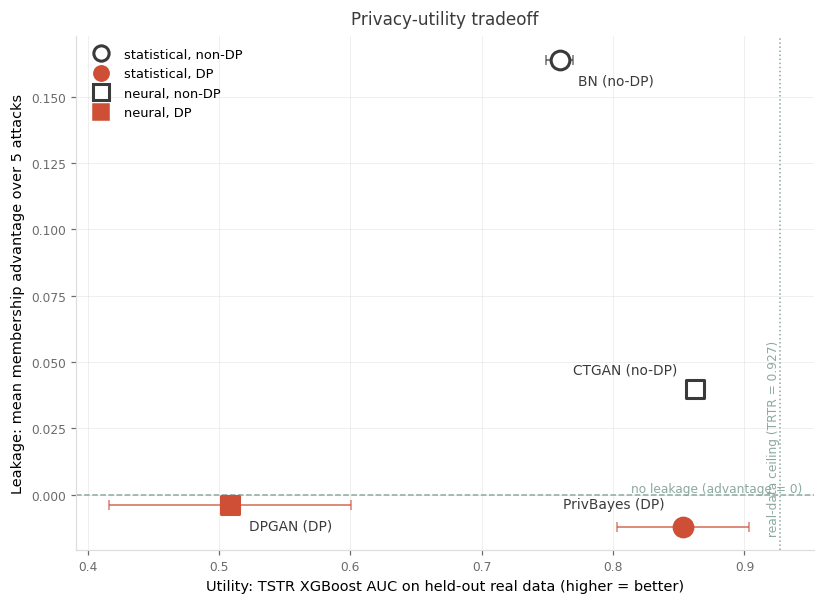

,method,label,dp,kind,mean_advantage,tstr_xgboost_auc_mean,tstr_xgboost_auc_std,trtr_xgboost_auc_mean
0,bayesian_network,BN (no-DP),False,statistical,0.164,0.7594,0.0103,0.9274
1,privbayes,PrivBayes (DP),True,statistical,-0.012,0.8534,0.0501,0.9274
2,ctgan,CTGAN (no-DP),False,neural,0.040,0.8626,0.0053,0.9274
3,dpgan,DPGAN (DP),True,neural,-0.004,0.5087,0.0921,0.9274


In [7]:
util = pd.read_csv(UTILITY_RESULTS) if UTILITY_RESULTS.exists() else None
fid = pd.read_csv(FIDELITY_RESULTS) if FIDELITY_RESULTS.exists() else None
assert util is not None, f"missing {UTILITY_RESULTS} -- run evaluation/eval_utility.py"

adv = per_attack.groupby("method")["mia_advantage"].mean()
trade = pd.DataFrame({
    "method": [m for m in METHODS if m in adv.index],
}).assign(
    label=lambda d: d.method.map(LABELS),
    dp=lambda d: d.method.map(lambda m: METHOD_CONFIG[m]["dp"]),
    kind=lambda d: d.method.map(lambda m: METHOD_CONFIG[m]["kind"]),
    mean_advantage=lambda d: d.method.map(adv),
).merge(util[["method", "tstr_xgboost_auc_mean", "tstr_xgboost_auc_std",
              "trtr_xgboost_auc_mean"]], on="method", how="left")
assert trade["tstr_xgboost_auc_mean"].notna().all(), "utility join produced NaN -- check method names"

fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.axhline(0.0, ls="--", lw=1, color=SAGE, zorder=1)
ax.text(0.99, 0.0, "no leakage (advantage = 0) ", transform=ax.get_yaxis_transform(),
        va="bottom", ha="right", fontsize=8, color=SAGE)
gt = float(trade["trtr_xgboost_auc_mean"].dropna().iloc[0])
ax.axvline(gt, ls=":", lw=1, color=SAGE, zorder=1)
ax.text(gt, 0.02, f" real-data ceiling (TRTR = {gt:.3f})", rotation=90,
        transform=ax.get_xaxis_transform(), va="bottom", ha="right", fontsize=8, color=SAGE)

OFFSET = {"dpgan": (12, -16), "ctgan": (-12, 10),
          "bayesian_network": (12, -16), "privbayes": (-12, 12)}
for _, r in trade.iterrows():
    col = ORANGE if r.dp else CHARCOAL
    ax.errorbar(r.tstr_xgboost_auc_mean, r.mean_advantage,
                xerr=r.tstr_xgboost_auc_std, fmt="none", ecolor=col, elinewidth=1.2,
                capsize=3, alpha=0.7, zorder=2)
    ax.scatter(r.tstr_xgboost_auc_mean, r.mean_advantage, s=150,
               marker="o" if r.kind == "statistical" else "s",
               facecolor=col if r.dp else "white", edgecolor=col, lw=2, zorder=3)
    dx, dy = OFFSET.get(r.method, (10, 10))
    ax.annotate(r.label, (r.tstr_xgboost_auc_mean, r.mean_advantage),
                textcoords="offset points", xytext=(dx, dy),
                ha="left" if dx > 0 else "right", fontsize=9, color=INK)

ax.set_xlabel("Utility: TSTR XGBoost AUC on held-out real data (higher = better)", fontsize=9.5)
ax.set_ylabel("Leakage: mean membership advantage over 5 attacks", fontsize=9.5)
ax.set_title("Privacy-utility tradeoff", fontsize=11, color=INK, pad=8)
tidy(ax); ax.grid(axis="y", color=GRID, lw=0.6, alpha=0.5)
ax.legend(handles=[
    Line2D([], [], marker="o", ls="none", mfc="white", mec=CHARCOAL, mew=2, ms=10, label="statistical, non-DP"),
    Line2D([], [], marker="o", ls="none", mfc=ORANGE, mec=ORANGE, ms=10, label="statistical, DP"),
    Line2D([], [], marker="s", ls="none", mfc="white", mec=CHARCOAL, mew=2, ms=10, label="neural, non-DP"),
    Line2D([], [], marker="s", ls="none", mfc=ORANGE, mec=ORANGE, ms=10, label="neural, DP"),
], loc="upper left", frameon=False, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "privacy_utility_tradeoff.png", bbox_inches="tight")
plt.show()
trade.round(4)

## 7. Summary tables

Ports `aggregate.py`. Writes `summary_privacy.csv`, `summary_utility.csv` and
`summary_combined.csv` to `results/tables/`, with assertions so a silently empty table cannot
recur.

In [8]:
UTILITY_COLS = ["tstr_xgboost_auc", "trtr_xgboost_auc", "retention_xgboost",
                "tstr_logistic_regression_auc", "retention_logistic_regression"]
FIDELITY_COLS = ["KSComplement", "TVComplement", "CorrelationSimilarity", "ContingencySimilarity"]

rows = []
for method, g in per_attack.groupby("method"):
    eps_low = g["eps_low_95"] if "eps_low_95" in g else pd.Series(dtype=float)
    max_eps_low = float(eps_low.max()) if len(eps_low) else np.nan
    rows.append({
        "method": method, "label": LABELS.get(method, method),
        "dp": bool(g["dp"].iloc[0]), "kind": g["kind"].iloc[0], "n_attacks": len(g),
        "worst_case_auc": float(g["auc"].max()),
        "worst_auc_attack": g.loc[g["auc"].idxmax(), "attack"],
        "mean_auc": float(g["auc"].mean()),
        "mean_advantage": float(g["mia_advantage"].mean()),
        "n_attacks_significant": int((mw.loc[mw.method == method, "p"] < ALPHA).sum()),
        "min_mannwhitney_p": float(mw.loc[mw.method == method, "p"].min()),
        "worst_case_eff_eps_low95": max_eps_low,
        "formal_epsilon": g["formal_epsilon"].iloc[0] if g["dp"].iloc[0] else np.nan,
        "num_train": METHOD_CONFIG.get(method, {}).get("num_train"),
        "num_test": METHOD_CONFIG.get(method, {}).get("num_test"),
        "auc_null_band_halfwidth": HW,
    })
order = {m: i for i, m in enumerate(METHODS)}
summary_privacy = (pd.DataFrame(rows).sort_values("method", key=lambda s: s.map(order))
                   .reset_index(drop=True))
summary_privacy.to_csv(TABLES_DIR / "summary_privacy.csv", index=False)

urows = []
for method in METHODS:
    row = {"method": method, "label": LABELS.get(method, method)}
    for src, cols, n_key in ((util, UTILITY_COLS, "n_utility_runs"),
                             (fid, FIDELITY_COLS, "n_fidelity_runs")):
        if src is None:
            continue
        sub = src[src["method"] == method]
        if not len(sub):
            continue
        row[n_key] = int(sub["n_runs"].iloc[0]) if "n_runs" in sub else np.nan
        for col in cols:
            for sfx in ("_mean", "_std"):
                row[f"{col}{sfx}"] = float(sub[f"{col}{sfx}"].iloc[0]) if f"{col}{sfx}" in sub else np.nan
    urows.append(row)
summary_utility = pd.DataFrame(urows)
assert "tstr_xgboost_auc_mean" in summary_utility, \
    "utility join produced a label-only table -- check that utility_summary.csv exists and has _mean columns"
assert summary_utility["tstr_xgboost_auc_mean"].notna().any(), "all utility values are NaN"
summary_utility.to_csv(TABLES_DIR / "summary_utility.csv", index=False)

keep_p = ["method", "label", "dp", "kind", "worst_case_auc", "mean_auc", "mean_advantage",
          "n_attacks_significant", "min_mannwhitney_p", "worst_case_eff_eps_low95",
          "formal_epsilon"]
keep_u = [c for c in ["method", "tstr_xgboost_auc_mean", "tstr_xgboost_auc_std",
                      "trtr_xgboost_auc_mean", "retention_xgboost_mean",
                      "tstr_logistic_regression_auc_mean",
                      "KSComplement_mean", "TVComplement_mean",
                      "ContingencySimilarity_mean"] if c in summary_utility.columns]
summary_combined = summary_privacy[keep_p].merge(summary_utility[keep_u], on="method", how="left")
summary_combined.to_csv(TABLES_DIR / "summary_combined.csv", index=False)

for p in ("summary_privacy.csv", "summary_utility.csv", "summary_combined.csv"):
    print("wrote", TABLES_DIR / p)
print()
summary_combined.round(4)

wrote /Users/PengOlivia/Desktop/Uni/USYD VRI/priv-sdg/benchmark_tapas/results/tables/summary_privacy.csv
wrote /Users/PengOlivia/Desktop/Uni/USYD VRI/priv-sdg/benchmark_tapas/results/tables/summary_utility.csv
wrote /Users/PengOlivia/Desktop/Uni/USYD VRI/priv-sdg/benchmark_tapas/results/tables/summary_combined.csv



,method,label,dp,kind,worst_case_auc,mean_auc,mean_advantage,n_attacks_significant,min_mannwhitney_p,worst_case_eff_eps_low95,formal_epsilon,tstr_xgboost_auc_mean,tstr_xgboost_auc_std,trtr_xgboost_auc_mean,retention_xgboost_mean,tstr_logistic_regression_auc_mean,KSComplement_mean,TVComplement_mean,ContingencySimilarity_mean
0,bayesian_network,BN (no-DP),False,statistical,0.6098,0.5694,0.164,0,0.0585,0.0,NaN,0.7594,0.0103,0.9274,0.8188,0.7561,0.7274,0.8966,0.7889
1,privbayes,PrivBayes (DP),True,statistical,0.5398,0.5142,-0.012,0,0.4948,0.0,1.0,0.8534,0.0501,0.9274,0.9202,0.8379,0.8524,0.9445,0.8911
2,ctgan,CTGAN (no-DP),False,neural,0.5922,0.4868,0.040,0,0.1124,0.0,NaN,0.8626,0.0053,0.9274,0.9301,0.8714,0.6638,0.8713,0.7717
3,dpgan,DPGAN (DP),True,neural,0.5496,0.4898,-0.004,0,0.0515,0.0,1.0,0.5087,0.0921,0.9274,0.5485,0.5585,0.2888,0.2480,0.0864


## 8. What the numbers say

Read this together with the tables above rather than from memory -- the cells re-run.

**Separation.** No generator x attack cell reaches p < 0.05 on the Mann-Whitney test. None of
the five attacks distinguishes whether the target was in the training data, for any of the four
generators. The directional pattern -- BayesNet closest to significance on most attacks, the DP
methods furthest -- is inside the noise and is a hypothesis, not a result.

**Decisiveness.** The large between-generator differences are in where the scores *sit*, not in
the member/non-member gap -- ClosestDistance sits near -0.25 for BayesNet and near -2.8 for
DPGAN. That is fidelity: how closely a generator reproduces the region around the target. These
attacks are measuring reproduction quality, not membership.

**Sample size is now the binding constraint**, which it was not before -- previously the audit had
an effective sample size of 2 regardless of the counts. Resolving an AUC of 0.55 needs the null
band under +-0.05, i.e. roughly 260 per class, so `num_test` around 520. TAPAS Experiment 2's
1000/2500 would give about +-0.023.

**Not yet answered.** Whether DP reduces empirical leakage. The point estimates lean that way for
the statistical pair, but nothing here is significant. Higher counts would settle it.